# Ach 4 IC Project Questions 2 & 4

# Table of Contents

__01. Importing analysis and visualization libraries and dataframe__

__02. Achievement 4 - IC Project Question 2__

__03. Achievement 4 - IC Project Question 4__

# 01. Importing analysis and visualization libraries and dataframe

In [1]:
# Import analysis and visualization libraries

import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import scipy

In [3]:
# Import dataframe

path = r'C:\Users\dirk8\CareerFoundry Projects\03-2025 Instacart Basket Analysis'
ords_prods_merge = pd.read_pickle(os.path.join(path, 'Data', 'Prepared Data', 'ords_prods_cust.pkl'))

In [7]:
# Check the dataframe

ords_prods_merge[56:61]

,order_id,user_id,order_number,orders_day_of_week,order_hour_of_day,days_since_prior_order,product_id,add_to_cart_order,reordered,product_name,...,order_frequency_flag,first_name,last_name,gender,state_name,age,date_joined,number_dependents,family_status,income
56,2550362,1,10,4,8,30.0,35951,7,0,Organic Unsweetened Almond Milk,...,Non-frequent customer,Linda,Nguyen,Female,Alabama,31,2019-02-17,3,married,40423
57,2550362,1,10,4,8,30.0,13032,8,1,Cinnamon Toast Crunch,...,Non-frequent customer,Linda,Nguyen,Female,Alabama,31,2019-02-17,3,married,40423
58,2550362,1,10,4,8,30.0,12427,9,1,Original Beef Jerky,...,Non-frequent customer,Linda,Nguyen,Female,Alabama,31,2019-02-17,3,married,40423
59,2168274,2,1,2,11,NaN,32792,1,0,Chipotle Beef & Pork Realstick,...,Regular customer,Norma,Chapman,Female,Alaska,68,2017-07-04,3,married,64940
60,2168274,2,1,2,11,NaN,47766,2,0,Organic Avocado,...,Regular customer,Norma,Chapman,Female,Alaska,68,2017-07-04,3,married,64940


In [9]:
# Check the dimensions
ords_prods_merge.shape

(32399732, 31)

In [11]:
# Check the middle columns
ords_prods_merge.iloc[56:61,8:15]

,reordered,product_name,aisle_id,department_id,prices,price_range_loc,busiest_day
56,0,Organic Unsweetened Almond Milk,91,16,1.3,Low-range product,Least busy
57,1,Cinnamon Toast Crunch,121,14,4.0,Low-range product,Least busy
58,1,Original Beef Jerky,23,19,4.4,Low-range product,Least busy
59,0,Chipotle Beef & Pork Realstick,23,19,5.2,Mid-range product,Regularly busy
60,0,Organic Avocado,24,4,6.3,Mid-range product,Regularly busy


# 02. Achievement 4 - IC Project Question 2

__Question 2: Are there particular times of the day when people spend the most money, as this might inform the type of products they advertise at these times?__

In [13]:
# Create a pivot table of spending per order hour of day

piv_table_hours = ords_prods_merge.pivot_table(values = 'prices', index = 'order_hour_of_day', aggfunc = 'sum').round()
piv_table_hours

,prices
order_hour_of_day,
0,1708627.0
1,902988.0
2,540953.0
3,401331.0
4,417265.0
5,688440.0
6,2270681.0
7,6967056.0
8,13383027.0


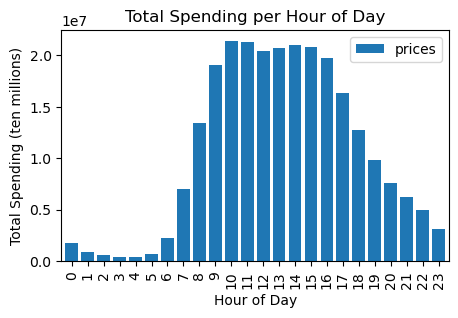

In [15]:
# Create a bar chart from piv_table_hours

hours_spend_bar = piv_table_hours.plot(kind='bar', figsize=(5, 3), width=0.8)

plt.title('Total Spending per Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Total Spending (ten millions)')
plt.show()

In [17]:
# Export bar chart

path = r'C:\Users\dirk8\CareerFoundry Projects\03-2025 Instacart Basket Analysis'
hours_spend_bar.figure.savefig(os.path.join(path, 'Analysis', 'Visualizations', 'hours_spend_bar.png'), bbox_inches = 'tight')

# 03. Achievement 4 - IC Project Question 4

__Question 4: Are there certain types of products more popular than other? Which departments have the highest frequency of product orders?__

# Order frequency per department

In [20]:
# Calculate frequency of product orders per department

ords_prods_merge['department_id'].value_counts()

department_id
4     9479291
16    5393620
19    2887550
7     2688123
1     2234743
13    1875369
3     1172428
15    1068058
20    1051249
9      866627
17     738666
12     708927
14     703033
11     447572
18     423802
6      269253
5      153696
8       97716
21      69145
2       36291
10      34573
Name: count, dtype: int64

# Total spending per department, for comparison

__Check total spending per department to compare with prior table measuring order counts__

In [77]:
# Specify a department dictionary to be used with the pivot_table() function to replace department_id values with full department names

department_labels = {1: 'frozen', 2: 'other', 3: 'bakery', 4: 'produce', 5: 'alcohol',6: 'international', 7: 'beverages', 8: 'pets', 9: 'dry goods pasta',10: 'bulk', 11: 'personal care', 12: 'meat seafood', 13: 'pantry',14: 'breakfast', 15: 'canned goods', 16: 'dairy eggs', 17: 'household',18: 'babies', 19: 'snacks', 20: 'deli', 21: 'missing'}

In [83]:
# Create pivot table showing total spending per department over time

piv_table_depts = ords_prods_merge.pivot_table(values = 'prices', index = 'department_id', aggfunc = 'sum').rename(index = department_labels).sort_values(by='prices', ascending=False)
piv_table_depts

,prices
department_id,
produce,75660934.5
dairy eggs,44956125.3
beverages,20646135.1
frozen,17289206.8
pantry,15020660.8
snacks,12345538.0
meat seafood,11551570.3
bakery,9208026.0
deli,8177351.8
